In [1]:
pip install h3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.2 MB/s eta 0:00:00


In [2]:
import h3
import csv
import geopandas as gpd
import pandas as pd

In [3]:
from shapely import Point, Polygon
from shapely import wkt
import json
import folium

In [5]:
gdf = gpd.read_file('/content/drive/MyDrive/Hubs/All_nodes+lines_21082025.csv', encoding='windows-1255')
gdf.set_index('Index', inplace=True)

In [6]:
gdf.head(3)

,node,LINE_ID,X,Y,geometry
Index,,,,,
0,467180,4.1_Arad-BS,188658.801,578137.8485,POINT (188658.80097229246 578137.8485002147)
1,467180,4.1_BS-Arad,188658.801,578137.8485,POINT (188658.80097229246 578137.8485002147)
2,467180,4.2_LRT_BRS-Shoket,188658.801,578137.8485,POINT (188658.80097229246 578137.8485002147)


In [7]:
gdf['geometry'] = gdf['geometry'].apply(wkt.loads)

In [8]:
gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs='2039')

<Axes: >

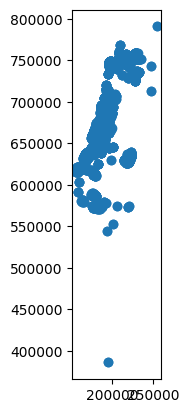

In [9]:
gdf.plot()

In [10]:
gdf.to_crs(4326, inplace=True)

<Axes: >

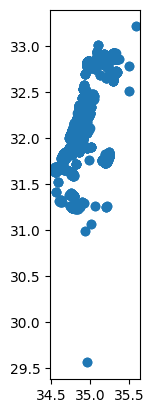

In [11]:
gdf.plot()

In [12]:
gdf['h3_index'] = gdf['geometry'].apply(lambda geom: h3.latlng_to_cell(geom.x, geom.y, 10))

In [13]:
def h3_to_polygon(h):
  return Polygon(h3.cell_to_boundary(h))


In [14]:
gdf['polygon'] = gdf['h3_index'].apply(h3_to_polygon)

In [15]:
h3_gdf = gpd.GeoDataFrame(gdf, geometry='polygon')

In [16]:
h3_gdf

,node,LINE_ID,X,Y,geometry,h3_index,polygon
Index,,,,,,,
0,467180,4.1_Arad-BS,188658.801,578137.8485,POINT (34.88097 31.29451),8a3f4c15cb87fff,"POLYGON ((34.88185 31.29445, 34.88119 31.29407..."
1,467180,4.1_BS-Arad,188658.801,578137.8485,POINT (34.88097 31.29451),8a3f4c15cb87fff,"POLYGON ((34.88185 31.29445, 34.88119 31.29407..."
2,467180,4.2_LRT_BRS-Shoket,188658.801,578137.8485,POINT (34.88097 31.29451),8a3f4c15cb87fff,"POLYGON ((34.88185 31.29445, 34.88119 31.29407..."
3,467180,4.2_LRT_Shoket-BRS,188658.801,578137.8485,POINT (34.88097 31.29451),8a3f4c15cb87fff,"POLYGON ((34.88185 31.29445, 34.88119 31.29407..."
4,467192,4.1_Arad-BS,185010.679,575447.1948,POINT (34.84275 31.27015),8a3f4c02da6ffff,"POLYGON ((34.84395 31.27007, 34.84329 31.26969..."
...,...,...,...,...,...,...,...
4865,400040,rail_3_2,184990.7663,679980.1923,POINT (34.83886 32.21285),8a3f4dc70517fff,"POLYGON ((34.83948 32.21256, 34.83882 32.21217..."
4866,511248,LRT121,185141.0951,680239.4503,POINT (34.84044 32.21519),8a3f4dc7052ffff,"POLYGON ((34.84089 32.21511, 34.84023 32.21472..."
4867,511248,LRT122,185141.0951,680239.4503,POINT (34.84044 32.21519),8a3f4dc7052ffff,"POLYGON ((34.84089 32.21511, 34.84023 32.21472..."


<Axes: >

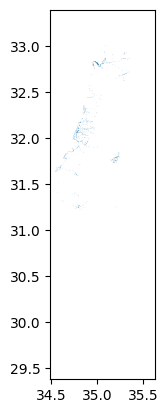

In [17]:
h3_gdf.plot()

In [18]:
center = h3_gdf.geometry.centroid
center = center.union_all().centroid.coords[0]

In [19]:
NO = True
if NO = False:
  print(1)

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (ipython-input-3819114158.py, line 2)

In [20]:
m = folium.Map(location=[center[1],center[0]], zoom_start=10)

In [21]:
h3_gdf.set_crs(4326, inplace=True)

,node,LINE_ID,X,Y,geometry,h3_index,polygon
Index,,,,,,,
0,467180,4.1_Arad-BS,188658.801,578137.8485,POINT (34.88097 31.29451),8a3f4c15cb87fff,"POLYGON ((34.88185 31.29445, 34.88119 31.29407..."
1,467180,4.1_BS-Arad,188658.801,578137.8485,POINT (34.88097 31.29451),8a3f4c15cb87fff,"POLYGON ((34.88185 31.29445, 34.88119 31.29407..."
2,467180,4.2_LRT_BRS-Shoket,188658.801,578137.8485,POINT (34.88097 31.29451),8a3f4c15cb87fff,"POLYGON ((34.88185 31.29445, 34.88119 31.29407..."
3,467180,4.2_LRT_Shoket-BRS,188658.801,578137.8485,POINT (34.88097 31.29451),8a3f4c15cb87fff,"POLYGON ((34.88185 31.29445, 34.88119 31.29407..."
4,467192,4.1_Arad-BS,185010.679,575447.1948,POINT (34.84275 31.27015),8a3f4c02da6ffff,"POLYGON ((34.84395 31.27007, 34.84329 31.26969..."
...,...,...,...,...,...,...,...
4865,400040,rail_3_2,184990.7663,679980.1923,POINT (34.83886 32.21285),8a3f4dc70517fff,"POLYGON ((34.83948 32.21256, 34.83882 32.21217..."
4866,511248,LRT121,185141.0951,680239.4503,POINT (34.84044 32.21519),8a3f4dc7052ffff,"POLYGON ((34.84089 32.21511, 34.84023 32.21472..."
4867,511248,LRT122,185141.0951,680239.4503,POINT (34.84044 32.21519),8a3f4dc7052ffff,"POLYGON ((34.84089 32.21511, 34.84023 32.21472..."


In [22]:
import json

In [23]:
import folium

In [24]:
def shapely_geojson_compatible(shape):
  """Converts a Shapely geometry to a GeoJSON-compatible format."""
  return shape.__geo_interface__


In [25]:
# Apply this function to the 'geometry' column to ensure GeoJSON compatibility
h3_gdf['geometry'] = h3_gdf['geometry'].apply(shapely_geojson_compatible)

In [26]:

# Now, try adding it to the folium map
folium.GeoJson(h3_gdf).add_to(m)

In [27]:
# Apply this function to the 'geometry' column to ensure GeoJSON compatibility
# Remove this line as it is causing the error:
# h3_gdf['geometry'] = h3_gdf['geometry'].apply(shapely_geojson_compatible)

# Now, try adding it to the folium map, passing the raw GeoDataFrame:
folium.GeoJson(h3_gdf, tooltip=folium.GeoJsonTooltip(fields=["h3_index"], aliases=["H3 Index:"])).add_to(m)

In [28]:
m

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# groupby h3_index
# lines = list/set?


In [ ]:
h3_gdf.head(3)

,node,LINE_ID,X,Y,geometry,h3_index,polygon
Index,,,,,,,
0,467180,4.1_Arad-BS,188658.801,578137.8485,"{'type': 'Point', 'coordinates': (34.880973999...",8a3f4c15cb87fff,"POLYGON ((34.88185 31.29445, 34.88119 31.29407..."
1,467180,4.1_BS-Arad,188658.801,578137.8485,"{'type': 'Point', 'coordinates': (34.880973999...",8a3f4c15cb87fff,"POLYGON ((34.88185 31.29445, 34.88119 31.29407..."
2,467180,4.2_LRT_BRS-Shoket,188658.801,578137.8485,"{'type': 'Point', 'coordinates': (34.880973999...",8a3f4c15cb87fff,"POLYGON ((34.88185 31.29445, 34.88119 31.29407..."


In [ ]:
# Load lines and planned mode
# join to get the planned mode into the database

In [29]:
# lines = pd.read_csv('/content/Lines_and_Planned_Mode_30-03-2025.csv', encoding='windows-1255')
lines = pd.read_csv('/content/drive/MyDrive/Hubs/Lines_and_Planned_Mode_13-08-2025.csv', encoding='windows-1255')

In [30]:
lines.head(3)

,Line_ModelName,Mode_Planned,Line_Name,Line_Description,Area
0,c001,Cable Line,רכבלית,לב המפרץ-אוניברסיטת חיפה,Haifa
1,c002,Cable Line,רכבלית,לב המפרץ-אוניברסיטת חיפה,Haifa
2,m0110a,BRT,מטרונית 1,מרכזית הקריות - חוף הכרמל,Haifa


In [32]:
remove_old_metronit = []
for line in lines[lines['Area']=='Haifa']['Line_ModelName'].to_list():
  if line[:1] == 'm':
    print(line, end=', ')
    remove_old_metronit.append(line)

m0110a, m0120a, m0210a, m0220a, m0310a, m0320a, m0410a, m0430a, m0510a, m0520a, m0610a, m0620a, m0710a, m0720a, m0810a, m0820a, m0910a, m0920a, m0610a, m0620a, m0630a, m0640a, m081#a, m082#a, m0810a, m0820a, m1010a, m1020a, m1410a, m1420a, m2010a, m2020a, 

In [33]:
remove_Netantya15 = []
for line in lines[lines['Area']=='Netanya']['Line_ModelName'].to_list():
  if line == 'LRT151' or line == 'LRT152':
    print(line, end=', ')
    remove_Netantya15.append(line)

LRT151, LRT152, 

In [ ]:
h3_gdf = h3_gdf[~h3_gdf['LINE_ID'].isin(remove_old_metronit)]
h3_gdf = h3_gdf[~h3_gdf['LINE_ID'].isin(remove_Netantya15)]

In [35]:
gdf = h3_gdf.merge(lines, left_on='LINE_ID', right_on='Line_ModelName', validate='many_to_many')

In [36]:
gdf

,node,LINE_ID,X,Y,geometry,h3_index,polygon,Line_ModelName,Mode_Planned,Line_Name,Line_Description,Area
0,467180,4.1_Arad-BS,188658.801,578137.8485,"{'type': 'Point', 'coordinates': (34.880973999...",8a3f4c15cb87fff,"POLYGON ((34.88185 31.29445, 34.88119 31.29407...",4.1_Arad-BS,LRT,ערד-באר שבע מערב,ערד-באר שבע מערב,Beer Sheva
1,467180,4.1_BS-Arad,188658.801,578137.8485,"{'type': 'Point', 'coordinates': (34.880973999...",8a3f4c15cb87fff,"POLYGON ((34.88185 31.29445, 34.88119 31.29407...",4.1_BS-Arad,LRT,ערד-באר שבע מערב,ערד-באר שבע מערב,Beer Sheva
2,467180,4.2_LRT_BRS-Shoket,188658.801,578137.8485,"{'type': 'Point', 'coordinates': (34.880973999...",8a3f4c15cb87fff,"POLYGON ((34.88185 31.29445, 34.88119 31.29407...",4.2_LRT_BRS-Shoket,LRT,"רק""ל ליקית",צומת שוקת-מרכז רפואי באר שבע,Beer Sheva
3,467180,4.2_LRT_Shoket-BRS,188658.801,578137.8485,"{'type': 'Point', 'coordinates': (34.880973999...",8a3f4c15cb87fff,"POLYGON ((34.88185 31.29445, 34.88119 31.29407...",4.2_LRT_Shoket-BRS,LRT,"רק""ל ליקית",צומת שוקת-מרכז רפואי באר שבע,Beer Sheva
4,467192,4.1_Arad-BS,185010.679,575447.1948,"{'type': 'Point', 'coordinates': (34.842750999...",8a3f4c02da6ffff,"POLYGON ((34.84395 31.27007, 34.84329 31.26969...",4.1_Arad-BS,LRT,ערד-באר שבע מערב,ערד-באר שבע מערב,Beer Sheva
...,...,...,...,...,...,...,...,...,...,...,...,...
5036,400040,rail_3_2,184990.7663,679980.1923,"{'type': 'Point', 'coordinates': (34.838858027...",8a3f4dc70517fff,"POLYGON ((34.83948 32.21256, 34.83882 32.21217...",rail_3_2,Interurban Rail,Beer Sheva-Nahariya,באר שבע-נהריה,National
5037,511248,LRT121,185141.0951,680239.4503,"{'type': 'Point', 'coordinates': (34.840443255...",8a3f4dc7052ffff,"POLYGON ((34.84089 32.21511, 34.84023 32.21472...",LRT121,LRT,קו כחול 1,נתניה מערב-הרצליה,Netanya
5038,511248,LRT122,185141.0951,680239.4503,"{'type': 'Point', 'coordinates': (34.840443255...",8a3f4dc7052ffff,"POLYGON ((34.84089 32.21511, 34.84023 32.21472...",LRT122,LRT,קו כחול 1,נתניה מערב-הרצליה,Netanya
5039,511248,LRT131,185141.0951,680239.4503,"{'type': 'Point', 'coordinates': (34.840443255...",8a3f4dc7052ffff,"POLYGON ((34.84089 32.21511, 34.84023 32.21472...",LRT131,LRT,קו כחול 2,נתניה מזרח-הרצליה,Netanya


In [37]:
# 2 step grouping
# 1. group by h3_index and mode planned
# 2. group the first step only by h3_index

hubs = gdf.groupby(['h3_index','node','Mode_Planned']).agg({'Line_ModelName': ['nunique','unique']})

In [38]:
hubs

Line_ModelName  \
                                             nunique   
h3_index        node  Mode_Planned                     
8a2da4100a27fff 31655 Interurban Rail              2   
8a2da4c22257fff 36963 BRT                          1   
8a2da4c22627fff 36959 BRT                          1   
8a2da4c2275ffff 36961 BRT                          2   
8a2da4c24987fff 36924 BRT                          4   
...                                              ...   
8a3f6b79ea07fff 51201 LRT                          4   
8a3f6b79ea8ffff 51200 LRT                          4   
8a3f6b79eb6ffff 51032 LRT                          4   
8a3f6b79ed2ffff 51004 LRT                          4   
8a3f6b79ed4ffff 51003 LRT                          4   

                                                                         
                                                                 unique  
h3_index        node  Mode_Planned                                       
8a2da4100a27fff 31655 Interurban Rail              [rail_1_1, rail_1_2]  
8a2da4c22257fff 36963 BRT                                      [brt022]  
8a2da4c22627fff 36959 BRT                                      [brt021]  
8a2da4c2275ffff 36961 BRT                              [brt021, brt022]  
8a2da4c24987fff 36924 BRT              [brt011, brt012, brt021, brt022]  
...                                                                 ...  
8a3f6b79ea07fff 51201 LRT                  [LRT11, LRT12, LRT51, LRT52]  
8a3f6b79ea8ffff 51200 LRT                  [LRT11, LRT12, LRT51, LRT52]  
8a3f6b79eb6ffff 51032 LRT                  [LRT11, LRT12, LRT51, LRT52]  
8a3f6b79ed2ffff 51004 LRT                  [LRT11, LRT12, LRT51, LRT52]  
8a3f6b79ed4ffff 51003 LRT                  [LRT11, LRT12, LRT51, LRT52]  

[1643 rows x 2 columns]

In [ ]:
hubs.to_csv('/content/hubs.csv', encoding='windows-1255')

In [40]:
read_hubs = pd.read_csv('/content/drive/MyDrive/Hubs/groups_hubs_21082025.csv')

In [41]:
read_hubs.head(3)

,h3_index,node,Mode_Planned,Area,Line_Nunique,Line_Unique,geometry,group,address
0,8a2da4100a27fff,31655,Interurban Rail,National,2,['rail_1_1' 'rail_1_2'],"POLYGON ((35.58265301880704 33.2100839260914, ...",0,"מנחם בגין/נורית, שדרות מנחם בגין, הורדים, קרית..."
1,8a2da4c22257fff,36963,BRT,Haifa,1,['brt022'],"POLYGON ((35.32671223620188 32.92554871232436,...",1,"מיי סנטר, מעלה כמון, אזור תעשייה כרמיאל, כרמיא..."
2,8a2da4c22627fff,36959,BRT,Haifa,1,['brt021'],POLYGON ((35.31703160566268 32.922357121183495...,2,"החרושת/חשמל, החרושת, אזור תעשייה כרמיאל, כרמיא..."


In [46]:
read_hubs.reset_index(inplace=True)

In [47]:
read_hubs['geometry'] = read_hubs['h3_index'].apply(lambda x: h3.cell_to_boundary(x))

In [ ]:
hubs

h3_index   node     Mode_Planned    Line  \
                                              nunique   
0     8a2da4100a27fff  31655  Interurban Rail       2   
1     8a2da4c22257fff  36963              BRT       1   
2     8a2da4c22627fff  36959              BRT       1   
3     8a2da4c2275ffff  36961              BRT       2   
4     8a2da4c24987fff  36924              BRT       4   
...               ...    ...              ...     ...   
1411  8a3f6b79ea07fff  51201              LRT       4   
1412  8a3f6b79ea8ffff  51200              LRT       4   
1413  8a3f6b79eb6ffff  51032              LRT       4   
1414  8a3f6b79ed2ffff  51004              LRT       4   
1415  8a3f6b79ed4ffff  51003              LRT       4   

                                        \
                                unique   
0                 [rail_1_1, rail_1_2]   
1                             [brt022]   
2                             [brt021]   
3                     [brt021, brt022]   
4     [brt011, brt012, brt021, brt022]   
...                                ...   
1411      [LRT11, LRT12, LRT51, LRT52]   
1412      [LRT11, LRT12, LRT51, LRT52]   
1413      [LRT11, LRT12, LRT51, LRT52]   
1414      [LRT11, LRT12, LRT51, LRT52]   
1415      [LRT11, LRT12, LRT51, LRT52]   

                                               geometry  
                                                         
0     ((35.58265301924393, 33.210083925527144), (35....  
1     ((35.326712236651176, 32.925548711745186), (35...  
2     ((35.31703160611188, 32.922357120604566), (35....  
3     ((35.31899096798917, 32.92353041082285), (35.3...  
4     ((35.34684915436387, 32.86202464606141), (35.3...  
...                                                 ...  
1411  ((35.237732049903876, 31.838357805304724), (35...  
1412  ((35.234487172891484, 31.837326237924138), (35...  
1413  ((35.24111742891735, 31.842073007406242), (35....  
1414  ((35.24055557947, 31.819199849245393), (35.239...  
1415  ((35.238862356692735, 31.82341185241202), (35....  

[1416 rows x 6 columns]

In [48]:
from shapely import Polygon

In [49]:
read_hubs['geometry'] = read_hubs['geometry'].apply(Polygon)

In [78]:
gdf = gpd.GeoDataFrame(read_hubs, geometry='geometry', crs='4326') # crs 2039

<Axes: >

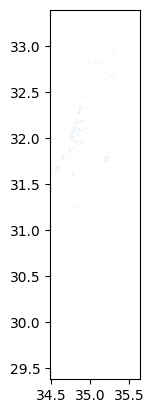

In [51]:
gdf.plot()

In [52]:
center = gdf.geometry.centroid
center = center.union_all().centroid.coords[0]

/tmp/ipython-input-1845341057.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = gdf.geometry.centroid


In [79]:
def shapely_geojson_compatible(shape):
  """Converts a Shapely geometry to a GeoJSON-compatible format."""
  return shape.__geo_interface__


In [80]:
gdf

,index,h3_index,node,Mode_Planned,Area,Line_Nunique,Line_Unique,geometry,group,address
0,0,8a2da4100a27fff,31655,Interurban Rail,National,2,['rail_1_1' 'rail_1_2'],"POLYGON ((35.58265 33.21008, 35.582 33.20969, ...",0,"מנחם בגין/נורית, שדרות מנחם בגין, הורדים, קרית..."
1,1,8a2da4c22257fff,36963,BRT,Haifa,1,['brt022'],"POLYGON ((35.32671 32.92555, 35.32606 32.92516...",1,"מיי סנטר, מעלה כמון, אזור תעשייה כרמיאל, כרמיא..."
2,2,8a2da4c22627fff,36959,BRT,Haifa,1,['brt021'],"POLYGON ((35.31703 32.92236, 35.31638 32.92197...",2,"החרושת/חשמל, החרושת, אזור תעשייה כרמיאל, כרמיא..."
3,3,8a2da4c2275ffff,36961,BRT,Haifa,2,['brt021' 'brt022'],"POLYGON ((35.31899 32.92353, 35.31834 32.92314...",2,"החרושת, אזור תעשייה כרמיאל, כרמיאל, נפת עכו, מ..."
4,4,8a2da4c24987fff,36924,BRT,Haifa,4,['brt011' 'brt012' 'brt021' 'brt022'],"POLYGON ((35.34685 32.86202, 35.3462 32.86163,...",3,"طريق الجليل, عرابة, נפת עכו, מחוז הצפון, 20176..."
...,...,...,...,...,...,...,...,...,...,...
1415,1415,8a3f6b79ea07fff,51201,LRT,Jerusalem,4,['LRT11' 'LRT12' 'LRT51' 'LRT52'],"POLYGON ((35.23773 31.83836, 35.23707 31.83797...",997,"33, נווה יעקב, פסגת זאב צפון, ירושלים | القدس,..."
1416,1416,8a3f6b79ea8ffff,51200,LRT,Jerusalem,4,['LRT11' 'LRT12' 'LRT51' 'LRT52'],"POLYGON ((35.23449 31.83733, 35.23383 31.83694...",998,"16, נווה יעקב, פסגת זאב צפון, ירושלים | القدس,..."
1417,1417,8a3f6b79eb6ffff,51032,LRT,Jerusalem,4,['LRT11' 'LRT12' 'LRT51' 'LRT52'],"POLYGON ((35.24112 31.84207, 35.24046 31.84169...",999,"25, נווה יעקב, נוה יעקב, ירושלים | القدس, נפת ..."
1418,1418,8a3f6b79ed2ffff,51004,LRT,Jerusalem,4,['LRT11' 'LRT12' 'LRT51' 'LRT52'],"POLYGON ((35.24056 31.8192, 35.2399 31.81881, ...",1000,"אלוף יקותיאל אדם, פסגת זאב מערב, פסגת זאב, ירו..."


In [81]:
gdf.columns

Index(['index', 'h3_index', 'node', 'Mode_Planned', 'Area', 'Line_Nunique',
       'Line_Unique', 'geometry', 'group', 'address'],
      dtype='object')

In [70]:
new_cols = [''.join(col).strip(' ') for col in gdf.columns.values]

In [82]:
gdf.columns = gdf.columns.to_flat_index()

In [83]:
# gdf.columns = new_cols
gdf.head(3)

,index,h3_index,node,Mode_Planned,Area,Line_Nunique,Line_Unique,geometry,group,address
0,0,8a2da4100a27fff,31655,Interurban Rail,National,2,['rail_1_1' 'rail_1_2'],"POLYGON ((35.58265 33.21008, 35.582 33.20969, ...",0,"מנחם בגין/נורית, שדרות מנחם בגין, הורדים, קרית..."
1,1,8a2da4c22257fff,36963,BRT,Haifa,1,['brt022'],"POLYGON ((35.32671 32.92555, 35.32606 32.92516...",1,"מיי סנטר, מעלה כמון, אזור תעשייה כרמיאל, כרמיא..."
2,2,8a2da4c22627fff,36959,BRT,Haifa,1,['brt021'],"POLYGON ((35.31703 32.92236, 35.31638 32.92197...",2,"החרושת/חשמל, החרושת, אזור תעשייה כרמיאל, כרמיא..."


In [ ]:
import numpy as np

In [ ]:
gdf.to_csv('/content/hubs_ungrouped.csv', encoding='windows-1255')

In [84]:
hubs_grouped = gdf.groupby(['h3_index']).agg({'Mode_Planned': set,
                                                     'Line_Nunique': list,
                                                     'Line_Unique': list})

In [ ]:
hubs_grouped.to_csv('/content/hubs_grouped_v2.csv', encoding='windows-1255')

In [86]:
hubs_grouped

,Mode_Planned,Line_Nunique,Line_Unique
h3_index,,,
8a2da4100a27fff,{Interurban Rail},[2],[['rail_1_1' 'rail_1_2']]
8a2da4c22257fff,{BRT},[1],[['brt022']]
8a2da4c22627fff,{BRT},[1],[['brt021']]
8a2da4c2275ffff,{BRT},[2],[['brt021' 'brt022']]
8a2da4c24987fff,{BRT},[4],[['brt011' 'brt012' 'brt021' 'brt022']]
...,...,...,...
8a3f6b79ea07fff,{LRT},[4],[['LRT11' 'LRT12' 'LRT51' 'LRT52']]
8a3f6b79ea8ffff,{LRT},[4],[['LRT11' 'LRT12' 'LRT51' 'LRT52']]
8a3f6b79eb6ffff,{LRT},[4],[['LRT11' 'LRT12' 'LRT51' 'LRT52']]


In [ ]:
cols = ['h3_index', 'node', 'Mode_Planned', 'Line_Nunique', 'Line_Unique', 'geometry']

In [85]:
gdf

,index,h3_index,node,Mode_Planned,Area,Line_Nunique,Line_Unique,geometry,group,address
0,0,8a2da4100a27fff,31655,Interurban Rail,National,2,['rail_1_1' 'rail_1_2'],"POLYGON ((35.58265 33.21008, 35.582 33.20969, ...",0,"מנחם בגין/נורית, שדרות מנחם בגין, הורדים, קרית..."
1,1,8a2da4c22257fff,36963,BRT,Haifa,1,['brt022'],"POLYGON ((35.32671 32.92555, 35.32606 32.92516...",1,"מיי סנטר, מעלה כמון, אזור תעשייה כרמיאל, כרמיא..."
2,2,8a2da4c22627fff,36959,BRT,Haifa,1,['brt021'],"POLYGON ((35.31703 32.92236, 35.31638 32.92197...",2,"החרושת/חשמל, החרושת, אזור תעשייה כרמיאל, כרמיא..."
3,3,8a2da4c2275ffff,36961,BRT,Haifa,2,['brt021' 'brt022'],"POLYGON ((35.31899 32.92353, 35.31834 32.92314...",2,"החרושת, אזור תעשייה כרמיאל, כרמיאל, נפת עכו, מ..."
4,4,8a2da4c24987fff,36924,BRT,Haifa,4,['brt011' 'brt012' 'brt021' 'brt022'],"POLYGON ((35.34685 32.86202, 35.3462 32.86163,...",3,"طريق الجليل, عرابة, נפת עכו, מחוז הצפון, 20176..."
...,...,...,...,...,...,...,...,...,...,...
1415,1415,8a3f6b79ea07fff,51201,LRT,Jerusalem,4,['LRT11' 'LRT12' 'LRT51' 'LRT52'],"POLYGON ((35.23773 31.83836, 35.23707 31.83797...",997,"33, נווה יעקב, פסגת זאב צפון, ירושלים | القدس,..."
1416,1416,8a3f6b79ea8ffff,51200,LRT,Jerusalem,4,['LRT11' 'LRT12' 'LRT51' 'LRT52'],"POLYGON ((35.23449 31.83733, 35.23383 31.83694...",998,"16, נווה יעקב, פסגת זאב צפון, ירושלים | القدس,..."
1417,1417,8a3f6b79eb6ffff,51032,LRT,Jerusalem,4,['LRT11' 'LRT12' 'LRT51' 'LRT52'],"POLYGON ((35.24112 31.84207, 35.24046 31.84169...",999,"25, נווה יעקב, נוה יעקב, ירושלים | القدس, נפת ..."
1418,1418,8a3f6b79ed2ffff,51004,LRT,Jerusalem,4,['LRT11' 'LRT12' 'LRT51' 'LRT52'],"POLYGON ((35.24056 31.8192, 35.2399 31.81881, ...",1000,"אלוף יקותיאל אדם, פסגת זאב מערב, פסגת זאב, ירו..."


In [89]:
import networkx as nx

In [90]:
import matplotlib.pyplot as plt

In [91]:
import numpy as np

In [92]:
# Reproject to a projected CRS for Israel (units in meters)
gdf = gdf.to_crs(2039)

# Now buffer with 200 meters
gdf["buffer"] = gdf.geometry.buffer(120)


In [93]:
gdf.head(3)

,index,h3_index,node,Mode_Planned,Area,Line_Nunique,Line_Unique,geometry,group,address,buffer
0,0,8a2da4100a27fff,31655,Interurban Rail,National,2,['rail_1_1' 'rail_1_2'],"POLYGON ((254717.95 790579.037, 254657.43 7905...",0,"מנחם בגין/נורית, שדרות מנחם בגין, הורדים, קרית...","POLYGON ((254837.895 790575.414, 254836.911 79..."
1,1,8a2da4c22257fff,36963,BRT,Haifa,1,['brt022'],"POLYGON ((230892.671 758964.972, 230831.636 75...",1,"מיי סנטר, מעלה כמון, אזור תעשייה כרמיאל, כרמיא...","POLYGON ((231012.596 758960.733, 231011.543 75..."
2,2,8a2da4c22627fff,36959,BRT,Haifa,1,['brt021'],"POLYGON ((229987.592 758610.001, 229926.547 75...",2,"החרושת/חשמל, החרושת, אזור תעשייה כרמיאל, כרמיא...","POLYGON ((230107.517 758605.745, 230106.462 75..."


In [87]:
np.all(gdf.iloc[idx,4] == gdf.iloc[pm,4])

NameError: name 'np' is not defined

In [94]:
# Spatial index
sindex = gdf.sindex

# Initialize Graph
G = nx.Graph()

for idx, geom in gdf['buffer'].items():
    G.add_node(idx)
    possible_matches_index = list(sindex.intersection(geom.bounds))
    # check if the same lines are on both nodes
    for pm in possible_matches_index:
      lines_pm = gdf.iloc[pm,4]
      lines_idx = gdf.iloc[idx,4]

      if pm != idx and set(lines_pm) == set(lines_idx):
        possible_matches_index.remove(pm)
    # Explicitly remove self from potential matches
    # possible_matches_index = [pm for pm in possible_matches_index if pm != idx]
    # possible matches without nodes with the same lines
    # for pm in possible_matches_index:
    #   # Check if the Series contains any True values
    #   if (pm != idx) and (gdf.groupby([gdf.index,'h3_index']).agg({'Line_Nunique': 'sum'}).loc[pm,'Line_Nunique'].gt(1).any()):  # or .any() if looking for any True value
    #     possible_matches_index.remove(pm)

    # Use gdf['buffer'] to access the column as a Series, then index with match_idx
    # actual_matches = [match_idx for match_idx in possible_matches_index if geom.intersects(gdf['buffer'].loc[match_idx])]
    for match_idx in possible_matches_index:
      lines_match_idx = gdf.iloc[match_idx,4]
      lines_idx = gdf.iloc[idx,4]

      if match_idx != idx and set(lines_match_idx) == set(lines_idx):
        possible_matches_index.remove(match_idx)
      if geom.intersects(gdf['buffer'].loc[match_idx]):
        G.add_edge(idx, match_idx)

      # elif gdf.groupby([gdf.index,'h3_index']).agg({'Line_Nunique': 'sum'}).loc[match_idx,'Line_Nunique']:
      #   G.add_edge(idx, match_idx)

    # for match_idx in actual_matches:
    #     G.add_edge(idx, match_idx)

    # print(f"Index {idx} matches {len(actual_matches)} neighbors.")

# Assign group IDs based on connected components
gdf['group'] = -1
for group_id, component in enumerate(nx.connected_components(G)):
    gdf.loc[list(component), 'group'] = group_id

# Drop the buffer column after grouping
gdf.drop(columns='buffer', inplace=True)

In [95]:
gdf['group'].nunique()

1144

In [96]:
gdf.head(3)

,index,h3_index,node,Mode_Planned,Area,Line_Nunique,Line_Unique,geometry,group,address
0,0,8a2da4100a27fff,31655,Interurban Rail,National,2,['rail_1_1' 'rail_1_2'],"POLYGON ((254717.95 790579.037, 254657.43 7905...",0,"מנחם בגין/נורית, שדרות מנחם בגין, הורדים, קרית..."
1,1,8a2da4c22257fff,36963,BRT,Haifa,1,['brt022'],"POLYGON ((230892.671 758964.972, 230831.636 75...",1,"מיי סנטר, מעלה כמון, אזור תעשייה כרמיאל, כרמיא..."
2,2,8a2da4c22627fff,36959,BRT,Haifa,1,['brt021'],"POLYGON ((229987.592 758610.001, 229926.547 75...",2,"החרושת/חשמל, החרושת, אזור תעשייה כרמיאל, כרמיא..."


In [ ]:
# plot the groups

In [97]:
import folium
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors


# filter out groups with 1 member
# group_counts = gdf['group'].value_counts()
# valid_groups = group_counts[group_counts > 1].index
# filtered_gdf = gdf[gdf['group'].isin(valid_groups)].copy()
filtered_gdf = gdf.copy()

# First, convert back to lat/lon for Folium (EPSG:4326)
filtered_gdf = filtered_gdf.to_crs(epsg=4326)

# Prepare map centered on the data
m = folium.Map(location=[filtered_gdf.geometry.centroid.y.mean(), filtered_gdf.geometry.centroid.x.mean()], zoom_start=12)

# Generate a color map for groups
group_ids = filtered_gdf['group'].unique()
colormap = cm.get_cmap('tab20', len(group_ids))
color_map = {group: colors.rgb2hex(colormap(i)) for i, group in enumerate(group_ids)}

# Add polygons to the map with tooltip
for _, row in filtered_gdf.iterrows():
    geo_json = folium.GeoJson(
        row.geometry,
        style_function=lambda feature, clr=color_map[row['group']]: {
            'fillColor': clr,
            'color': clr,
            'weight': 1,
            'fillOpacity': 0.6,
        }
    )
    folium.Popup(f"Group: {row['group']}, Node: {row['node']}, 'Modes': {row['Mode_Planned']}, 'Lines': {row['Line_Unique']}").add_to(geo_json)
    geo_json.add_to(m)
# Mode_Planned	Line_Nunique	Line_Unique
# Display the map
m


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# filter out two steps:
# 1. h3 index with only one mode and 1 line, with no neighbor

In [ ]:
filtered_gdf['group'].nunique()

1002

In [ ]:
import geopy

In [ ]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

In [ ]:
geolocator = Nominatim(user_agent="h3_geocoder")
geocode = RateLimiter(geolocator.reverse, min_delay_seconds=1)

In [ ]:
filtered_gdf['centroid'] = filtered_gdf.geometry.centroid
filtered_gdf['lat'] = filtered_gdf.centroid.y
filtered_gdf['lon'] = filtered_gdf.centroid.x

<ipython-input-57-f356ed1ba1f5>:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  filtered_gdf['centroid'] = filtered_gdf.geometry.centroid
<ipython-input-57-f356ed1ba1f5>:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  filtered_gdf['lat'] = filtered_gdf.centroid.y
<ipython-input-57-f356ed1ba1f5>:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  filtered_gdf['lon'] = filtered_gdf.centroid.x


In [ ]:
filtered_gdf.to_csv('/content/all_groups_with_geometry.csv', encoding='windows-1255')

In [ ]:
# from geopy.geocoders import Nominatim
# from geopy.extra.rate_limiter import RateLimiter
# import geopandas as gpd

# Convert gdf to lat/lon for reverse geocoding
filtered_gdf = filtered_gdf.to_crs(epsg=4326)

# Initialize geocoder
geolocator = Nominatim(user_agent="h3_geocoder")
geocode = RateLimiter(geolocator.reverse, min_delay_seconds=1)

# Get centroid of each polygon for geocoding
filtered_gdf['centroid'] = filtered_gdf.geometry.centroid
filtered_gdf['lat'] = filtered_gdf.centroid.y
filtered_gdf['lon'] = filtered_gdf.centroid.x

# Reverse geocode function
def reverse_geocode(row):
  location = geocode((row['lat'], row['lon']), exactly_one=True)
  return location.address if location else None

# Apply reverse geocoding
filtered_gdf['address'] = filtered_gdf.apply(reverse_geocode, axis=1)

# Drop temporary columns if desired
filtered_gdf.drop(columns=['centroid', 'lat', 'lon'], inplace=True)


<ipython-input-59-211a008e3e9e>:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  filtered_gdf['centroid'] = filtered_gdf.geometry.centroid
<ipython-input-59-211a008e3e9e>:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  filtered_gdf['lat'] = filtered_gdf.centroid.y
<ipython-input-59-211a008e3e9e>:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  filtered_gdf['lon'] = filtered_gdf.centroid.x


In [ ]:

filtered_gdf.to_csv('/content/grouped_hubs_with_address_09042025.csv', encoding='utf-8')

In [ ]:
filtered_gdf.to_file('/content/filtered_hubs_hex_09042025.shp')

<ipython-input-61-68a41c25059a>:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  filtered_gdf.to_file('/content/filtered_hubs_hex_09042025.shp')
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Mode_Planned' to 'Mode_Plann'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Line_Nunique' to 'Line_Nuniq'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Line_Unique' to 'Line_Uniqu'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Value '127, פאול גרונינגר, קריית אלעזר, יוספטל - קריית אלון - קריית אלעזר, פתח תקווה, עיריית הוד השרון - מינהל הכספים, נפת פתח תקווה, מחוז המרכז, 4932404, ישראל' of field address has been truncated to 254 characters.  This warning will not be emitted any more for t

In [ ]:
filtered_gdf[filtered_gdf['group']==340]

,h3_index,node,Mode_Planned,Line_Nunique,Line_Unique,geometry,group,address
442,8a3f4cb61327fff,51166,LRT,2,"[LRT71, LRT72]","POLYGON ((35.22036 31.76318, 35.21971 31.7628,...",340,"32, עמק רפאים, המושבה הגרמנית, ירושלים, נפת יר..."


In [ ]:
# tag with gush-helka

In [ ]:
ownership = pd.read_csv('/content/Cadester_clean grouped by GushH.csv', encoding='windows-1255')

In [ ]:
ownership.head(3)

,GroupedBy(GushHelka),Count(GushHelka),Ownership
0,1000_13,1,State
1,1000_16,1,State
2,1000_17,1,State


In [ ]:
filtered_gdf.to_file('/content/grouped_hubs_with_address.geojson', driver='GeoJSON')

In [ ]:
filtered_gdf.to_file('/content/grouped_hubs_with_address.shp')

<ipython-input-372-4653c554bd94>:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  filtered_gdf.to_file('/content/grouped_hubs_with_address.shp')
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Mode_Planned' to 'Mode_Plann'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Line_Nunique' to 'Line_Nuniq'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Line_Unique' to 'Line_Uniqu'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Value '127, פאול גרונינגר, קריית אלעזר, יוספטל - קריית אלון - קריית אלעזר, פתח תקווה, עיריית הוד השרון - מינהל הכספים, נפת פתח תקווה, מחוז המרכז, 4932404, ישראל' of field address has been truncated to 254 characters.  This warning will not be emitted any more for t

In [ ]:
# assign new group to suspected nodes

In [ ]:
filtered_gdf

,h3_index,node,Mode_Planned,Line_Nunique,Line_Unique,geometry,group,address
0,8a2da4100a27fff,31655,Interurban Rail,2,"[rail_1_1, rail_1_2]","POLYGON ((35.58265 33.21008, 35.582 33.20969, ...",0,"מנחם בגין/נורית, שדרות מנחם בגין, הורדים, קרית..."
1,8a2da4c22257fff,36963,BRT,1,[brt022],"POLYGON ((35.32671 32.92555, 35.32606 32.92516...",1,"מיי סנטר, מעלה כמון, אזור תעשייה כרמיאל, כרמיא..."
2,8a2da4c22627fff,36959,BRT,1,[brt021],"POLYGON ((35.31703 32.92236, 35.31638 32.92197...",2,"החרושת/חשמל, החרושת, אזור תעשייה כרמיאל, כרמיא..."
3,8a2da4c2275ffff,36961,BRT,2,"[brt021, brt022]","POLYGON ((35.31899 32.92353, 35.31834 32.92314...",2,"החרושת, אזור תעשייה כרמיאל, כרמיאל, נפת עכו, מ..."
4,8a2da4c24987fff,36924,BRT,4,"[brt011, brt012, brt021, brt022]","POLYGON ((35.34685 32.86202, 35.3462 32.86163,...",3,"طريق الجليل, عرابة, נפת עכו, מחוז הצפון, 20176..."
...,...,...,...,...,...,...,...,...
1411,8a3f6b79ea07fff,51201,LRT,4,"[LRT11, LRT12, LRT51, LRT52]","POLYGON ((35.23773 31.83836, 35.23707 31.83797...",997,"33, נווה יעקב, פסגת זאב צפון, ירושלים | القدس,..."
1412,8a3f6b79ea8ffff,51200,LRT,4,"[LRT11, LRT12, LRT51, LRT52]","POLYGON ((35.23449 31.83733, 35.23383 31.83694...",998,"16, נווה יעקב, פסגת זאב צפון, ירושלים | القدس,..."
1413,8a3f6b79eb6ffff,51032,LRT,4,"[LRT11, LRT12, LRT51, LRT52]","POLYGON ((35.24112 31.84207, 35.24046 31.84169...",999,"25, נווה יעקב, נוה יעקב, ירושלים | القدس, נפת ..."
1414,8a3f6b79ed2ffff,51004,LRT,4,"[LRT11, LRT12, LRT51, LRT52]","POLYGON ((35.24056 31.8192, 35.2399 31.81881, ...",1000,"אלוף יקותיאל אדם, פסגת זאב מערב, פסגת זאב, ירו..."


In [ ]:
new_group = pd.read_csv('/content/suspected_nodes_assign_new_group.csv')

In [ ]:
filtered_gdf[filtered_gdf['node']=='36987']

,h3_index,node,Mode_Planned,Line_Nunique,Line_Unique,geometry,group,address
45,8a2da4d3468ffff,36987,BRT,2,"[brt031, brt032]","POLYGON ((35.29923 32.69289, 35.29857 32.6925,...",33,"مفرق هَمحتسڤوت, 75, الناصرة, נפת יזרעאל, מחוז ..."


In [ ]:
filtered_gdf[filtered_gdf['node']=='35023']

,h3_index,node,Mode_Planned,Line_Nunique,Line_Unique,geometry,group,address
48,8a2da4d346c7fff,35023,BRT,2,"[brt032, brt042]","POLYGON ((35.30119 32.69406, 35.30054 32.69367...",33,"ארמון האגמון, الناصرة, נפת יזרעאל, מחוז הצפון,..."


In [ ]:
filtered_gdf[filtered_gdf['group']==33]

,h3_index,node,Mode_Planned,Line_Nunique,Line_Unique,geometry,group,address
45,8a2da4d3468ffff,36987,BRT,2,"[brt031, brt032]","POLYGON ((35.29923 32.69289, 35.29857 32.6925,...",33,"مفرق هَمحتسڤوت, 75, الناصرة, נפת יזרעאל, מחוז ..."
47,8a2da4d346c7fff,34034,LRT,3,"[lrt01, lrt03, lrt05]","POLYGON ((35.30119 32.69406, 35.30054 32.69367...",33,"ארמון האגמון, الناصرة, נפת יזרעאל, מחוז הצפון,..."
48,8a2da4d346c7fff,35023,BRT,2,"[brt032, brt042]","POLYGON ((35.30119 32.69406, 35.30054 32.69367...",33,"ארמון האגמון, الناصرة, נפת יזרעאל, מחוז הצפון,..."
49,8a2da4d346d7fff,36964,BRT,4,"[brt031, brt032, brt041, brt042]","POLYGON ((35.29992 32.69417, 35.29927 32.69378...",33,"توفيق زياد, الناصرة, נפת יזרעאל, מחוז הצפון, 1..."
50,8a2da4d346d7fff,36965,BRT,4,"[brt031, brt032, brt041, brt042]","POLYGON ((35.29992 32.69417, 35.29927 32.69378...",33,"توفيق زياد, الناصرة, נפת יזרעאל, מחוז הצפון, 1..."


In [ ]:
new_group[new_group['node']=='36965']

,NewGroup,node,Unnamed: 2


In [ ]:
filtered_gdf['node'] = filtered_gdf['node'].astype('int64')

In [ ]:
for idx, row in new_group.iterrows():
  # print(idx, row['node'])
  filtered_gdf.loc[filtered_gdf['node']==row['node'], 'group'] = row['NewGroup']

In [ ]:
# clean up - finished

In [ ]:
# filtering -> no less than 1000 passengers daily

In [ ]:
filtered_gdf.head(3)

,h3_index,node,Mode_Planned,Line_Nunique,Line_Unique,geometry,group,address
0,8a2da4100a27fff,31655,Interurban Rail,2,"[rail_1_1, rail_1_2]","POLYGON ((35.58265 33.21008, 35.582 33.20969, ...",0,"מנחם בגין/נורית, שדרות מנחם בגין, הורדים, קרית..."
1,8a2da4c22257fff,36963,BRT,1,[brt022],"POLYGON ((35.32671 32.92555, 35.32606 32.92516...",1,"מיי סנטר, מעלה כמון, אזור תעשייה כרמיאל, כרמיא..."
2,8a2da4c22627fff,36959,BRT,1,[brt021],"POLYGON ((35.31703 32.92236, 35.31638 32.92197...",2,"החרושת/חשמל, החרושת, אזור תעשייה כרמיאל, כרמיא..."


In [ ]:
filtered_gdf.to_csv('/content/filtered_groups_09042025.csv', encoding='utf-8')

In [ ]:
hubs = pd.read_csv('/content/Hubs_groups_with_full_data_flat.csv', encoding='windows-1255')

FileNotFoundError: [Errno 2] No such file or directory: '/content/Hubs_groups_with_full_data_flat.csv'

In [ ]:
hubs.head(3)

,Column1,h3_index,node,Mode_Planned,Line_Nunique,Line_Unique,LandOwnership,Region,Location,Boardings_Daily,Alightings_Daily,TotalDemand_Daily,geometry,group,address
0,0,8a2da4100a27fff,31655,HighSpeed Rail,2,['rail_1_1' 'rail_1_2'],State,Haifa,Outer,2889.817785,147.867556,3037.685341,"POLYGON ((35.58265301880704 33.2100839260914, ...",0,"מנחם בגין/נורית, שדרות מנחם בגין, הורדים, קרית..."
1,1,8a2da4c22257fff,36963,BRT,1,['brt022'],State,Haifa,Outer,289.4615591,631.0450865,920.506646,"POLYGON ((35.32671223620188 32.92554871232436,...",1,"מיי סנטר, מעלה כמון, אזור תעשייה כרמיאל, כרמיא..."
2,2,8a2da4c22627fff,36959,BRT,1,['brt021'],State,Haifa,Outer,0,0.56331008,0.563310,POLYGON ((35.31703160566268 32.922357121183495...,2,"החרושת/חשמל, החרושת, אזור תעשייה כרמיאל, כרמיא..."


In [ ]:
# group by group id
# remove duplicates from total demand
# filter out demand under 1000

In [ ]:
hubs.columns

Index(['Column1', 'h3_index', 'node', 'Mode_Planned', 'Line_Nunique',
       'Line_Unique', 'LandOwnership', 'Region', 'Location', 'Boardings_Daily',
       'Alightings_Daily', 'TotalDemand_Daily', 'geometry', 'group',
       'address'],
      dtype='object')

In [ ]:
Grouped = hubs.groupby('group').agg(
    h3_index=('h3_index', 'unique'),
    address=('address', 'unique'),
    service_types=('Mode_Planned', 'unique'),
    Num_Modes=('Mode_Planned', 'nunique'),
    Mode_Score=('mode_score', 'sum'),
    Line_Nunique=('Line_Nunique', 'sum'),
    LandOwnership_category=('LandOwnership_category', 'min'),
    Region_category=('Region_category', 'min'),
    Location_category=('Location_category', 'min'),
    TotalDemand_Daily=('TotalDemand_Daily', lambda x: df.loc[x.index].drop_duplicates('node')['TotalDemand_Daily'].sum())
)

In [ ]:
import geopandas as gpd

In [ ]:
import